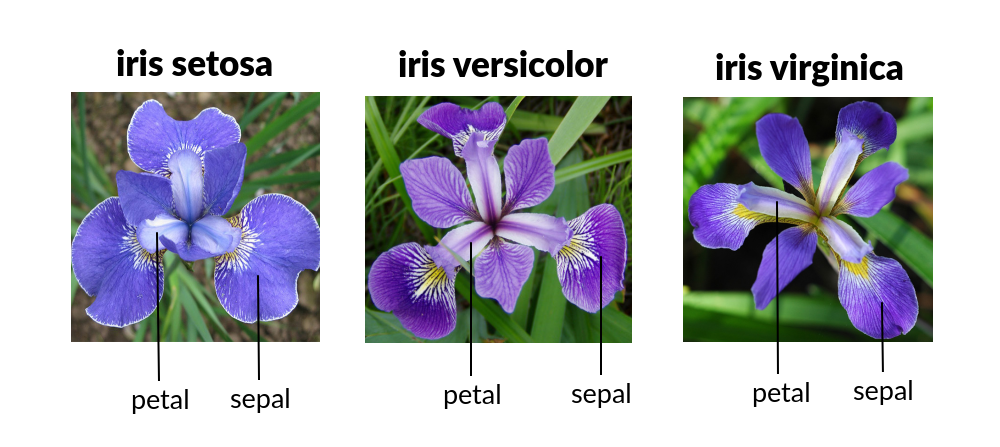

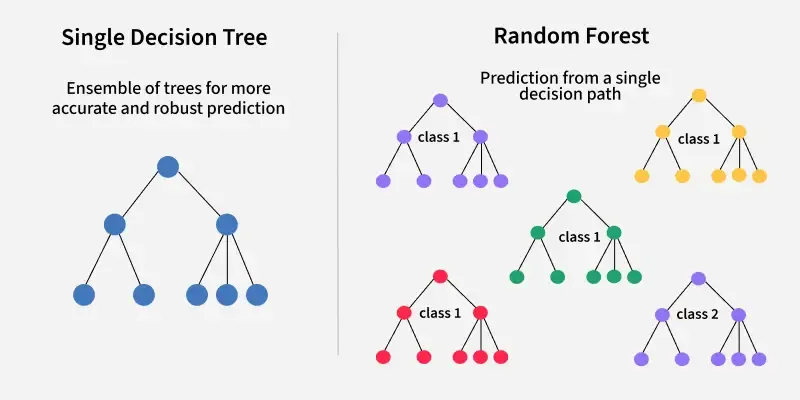

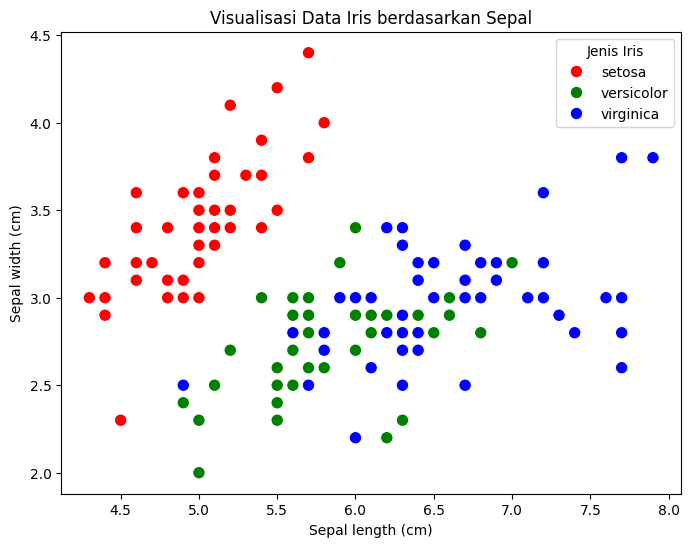

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris

# Load dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = [iris.target_names[i] for i in iris.target]  # mapping angka ke nama

# Scatter plot dengan warna sesuai species
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x="sepal length (cm)",
    y="sepal width (cm)",
    hue="species",          # pakai nama bunga, bukan angka
    palette={"setosa":"red", "versicolor":"green", "virginica":"blue"}, # atur warna manual
    s=80
)
plt.xlabel("Sepal length (cm)")
plt.ylabel("Sepal width (cm)")
plt.title("Visualisasi Data Iris berdasarkan Sepal")
plt.legend(title="Jenis Iris")
plt.show()

In [ ]:
# Memuat Library
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Memuat dataset Iris
iris = load_iris()
X, y = iris.data, iris.target

# Membagi data menjadi set pelatihan (80%) dan set pengujian (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inisialisasi model RandomForestClassifier dengan 100 pohon keputusan (estimators)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Membuat prediksi terhadap data pengujian
y_pred = model.predict(X_test)

# Mengevaluasi akurasi model dengan membandingkan hasil prediksi dengan label asli
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')


Accuracy: 1.00


In [1]:
import pandas as pd  # Library untuk menampilkan data dalam bentuk tabel
from sklearn.datasets import load_iris  # Mengimpor dataset Iris dari sklearn
from sklearn.model_selection import train_test_split  # Untuk membagi data menjadi set pelatihan dan pengujian
from sklearn.ensemble import RandomForestClassifier  # Menggunakan model Random Forest untuk klasifikasi
from sklearn.metrics import accuracy_score  # Untuk mengukur akurasi model

# Memuat dataset Iris yang berisi tiga jenis bunga iris dengan 4 fitur tiap sampel
iris = load_iris()
X, y = iris.data, iris.target  # X adalah fitur (panjang sepal, lebar sepal, panjang petal, lebar petal), y adalah label kelas bunga

# Mengonversi data ke dalam format DataFrame agar lebih mudah dibaca
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

# Menampilkan lima data pertama dari dataset dalam bentuk tabel
print("Contoh Data Iris:")
print(df.head())

# Menampilkan beberapa target yang berbeda dan jumlahnya
print("\nJumlah data untuk setiap kelas target:")
target_counts = df['target'].value_counts().sort_index()
for i, count in enumerate(target_counts):
    print(f"{iris.target_names[i]} ({i}): {count}")

# Membagi data menjadi set pelatihan (80%) dan set pengujian (20%) secara acak
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Menampilkan jumlah data pelatihan dan pengujian
print("\nJumlah data pelatihan:", len(X_train))
print("Jumlah data pengujian:", len(X_test))

# Inisialisasi model RandomForestClassifier dengan 100 pohon keputusan (estimators)
model = RandomForestClassifier(n_estimators=100, random_state=42)  # Model menggunakan 100 pohon keputusan untuk meningkatkan akurasi

# Melatih model menggunakan data pelatihan
model.fit(X_train, y_train)  # Model belajar dari pola dalam data pelatihan

# Membuat prediksi terhadap data pengujian
y_pred = model.predict(X_test)  # Model memprediksi kelas bunga berdasarkan fitur dari data pengujian

# Mengevaluasi akurasi model dengan membandingkan hasil prediksi dengan label asli
accuracy = accuracy_score(y_test, y_pred)  # Menghitung persentase prediksi yang benar
print(f'Accuracy: {accuracy:.2f}')  # Menampilkan akurasi dalam format dua desimal

# Inputan uji coba
print("\nMasukkan data untuk menguji model:")
input_data = []
for feature in iris.feature_names:
    value = float(input(f"{feature}: "))  # Meminta inputan dari pengguna untuk tiap fitur
    input_data.append(value)

# Mengubah inputan ke dalam format array untuk prediksi
import numpy as np
input_array = np.array(input_data).reshape(1, -1)
prediction = model.predict(input_array)

# Menampilkan hasil prediksi
print("\nHasil Prediksi:")
print(f"Bunga iris diprediksi sebagai: {iris.target_names[prediction[0]]}")


Contoh Data Iris:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Jumlah data untuk setiap kelas target:
setosa (0): 50
versicolor (1): 50
virginica (2): 50

Jumlah data pelatihan: 120
Jumlah data pengujian: 30
Accuracy: 1.00

Masukkan data untuk menguji model:
sepal length (cm): 3
sepal width (cm): 2
petal length (cm): 4
petal width (cm): 5

Hasil Prediksi:
Bunga iris diprediksi sebagai: virginica


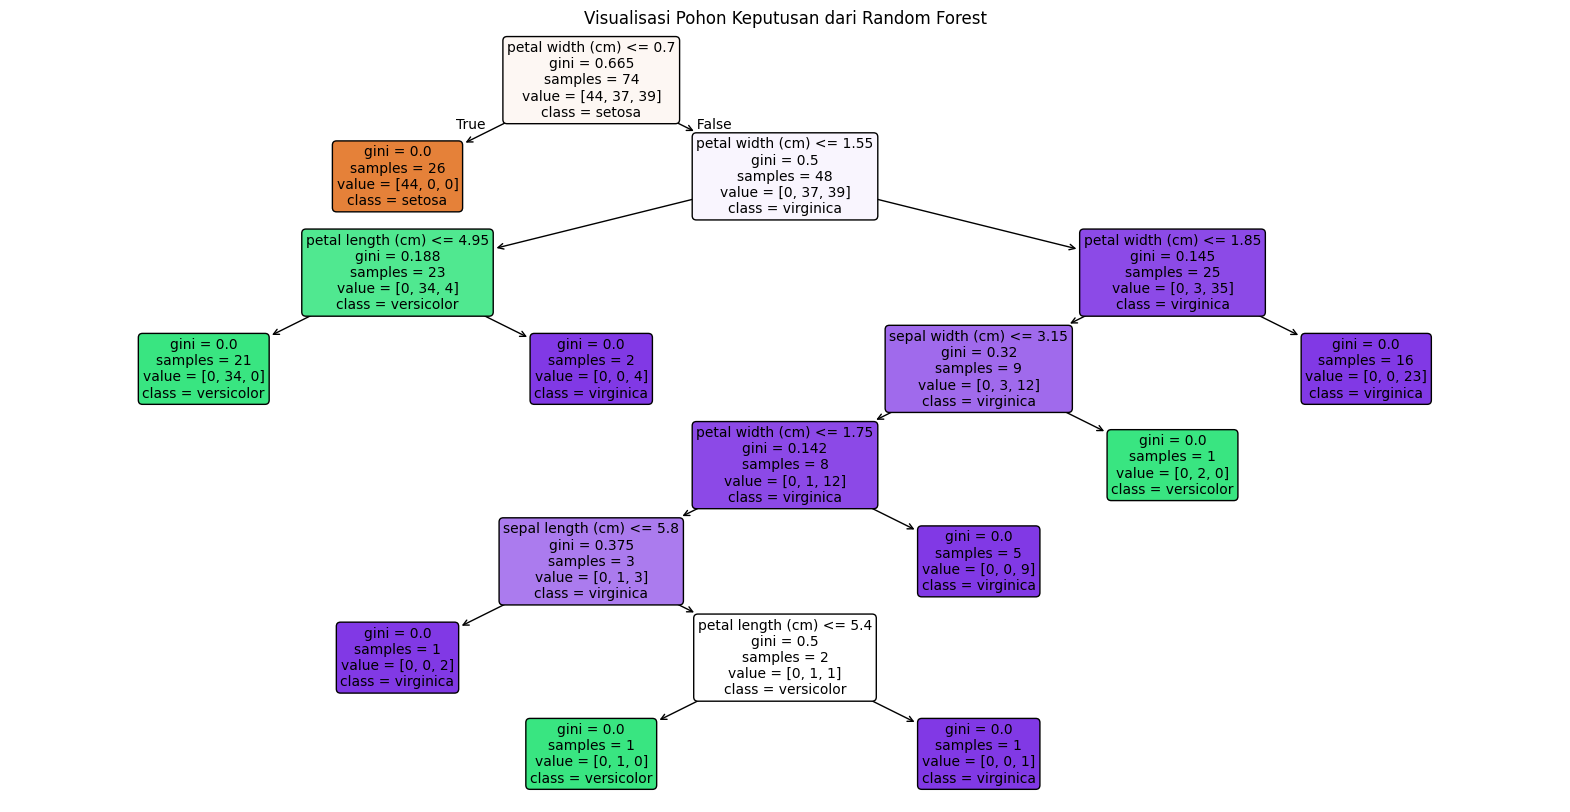

In [ ]:
from sklearn import tree
import matplotlib.pyplot as plt

# Ambil salah satu pohon dari Random Forest (misalnya pohon ke-0)
estimator = model.estimators_[0]

plt.figure(figsize=(20,10))
tree.plot_tree(estimator,
               feature_names=iris.feature_names,
               class_names=iris.target_names,
               filled=True,      # memberi warna sesuai kelas
               rounded=True,     # bentuk node membulat
               fontsize=10)
plt.title("Visualisasi Pohon Keputusan dari Random Forest")
plt.show()
